In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Set Seed**

In [2]:
import random
import numpy as np
import tensorflow as tf
import os

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

In [3]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/40X"   # adjust if different
OUTPUT_PATH = "/kaggle/working/train1"

# Classes in dataset
classes = ["benign","malignant"]
os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied.")

print("All class images copied into train folder.")

Class benign: 625 images copied.
Class malignant: 1370 images copied.
All class images copied into train folder.


In [4]:
train_dir = "/kaggle/working/train1"

# **Data Visualization**

Classes: ['malignant', 'benign']


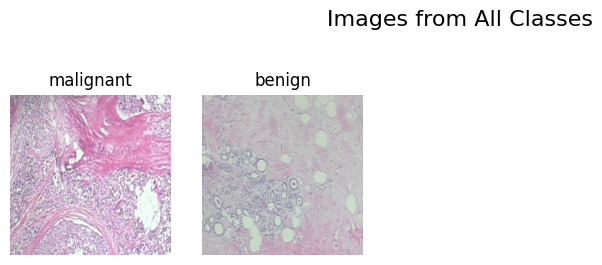

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipykernel_58/3288521508.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=he_colors)


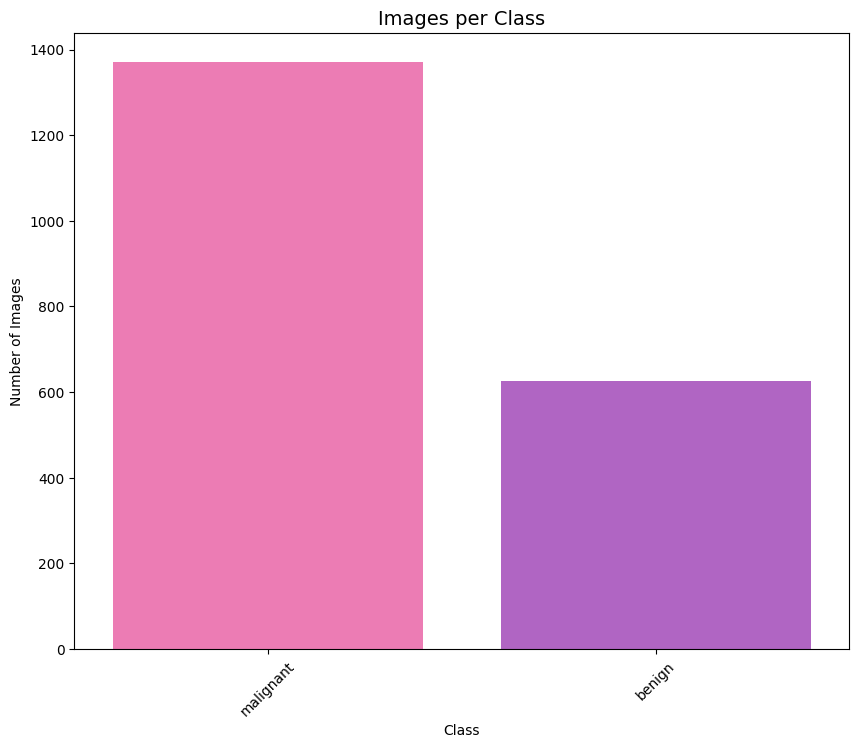

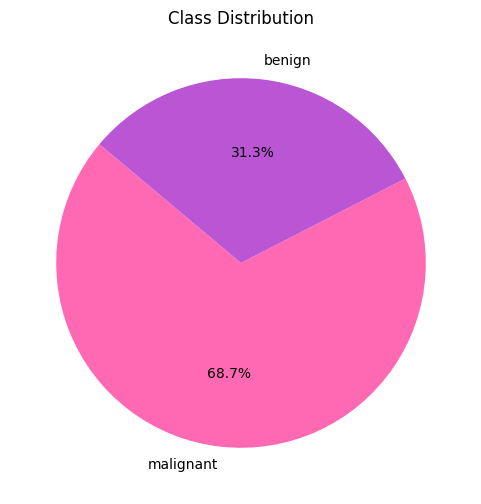

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# H&E-inspired colors (purple/blue + pink)
he_colors = ["#FF69B4", "#BA55D3"]

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=he_colors)
plt.xticks(rotation=45)
plt.title("Images per Class", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(kind="pie", autopct="%1.1f%%",
                                    startangle=140, figsize=(6,6),
                                    colors=he_colors)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# **Label Encoding**

In [7]:
import os
import pandas as pd
from PIL import Image
import numpy as np

all_images = []
all_labels = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        all_images.append(os.path.join(cls_path, img_name))
        all_labels.append(cls)

df = pd.DataFrame({"image_path": all_images, "label": all_labels})

# Preview
df.head()

,image_path,label
0,/kaggle/working/train1/malignant/SOB_M_PC-14-1...,malignant
1,/kaggle/working/train1/malignant/SOB_M_MC-14-1...,malignant
2,/kaggle/working/train1/malignant/SOB_M_DC-14-1...,malignant
3,/kaggle/working/train1/malignant/SOB_M_DC-14-2...,malignant
4,/kaggle/working/train1/malignant/SOB_M_DC-14-1...,malignant


In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["label_num"] = encoder.fit_transform(df["label"])

# Convert to string for stratification
df['label_num'] = df['label_num'].astype(str)

# Preview
df.head()

,image_path,label,label_num
0,/kaggle/working/train1/malignant/SOB_M_PC-14-1...,malignant,1
1,/kaggle/working/train1/malignant/SOB_M_MC-14-1...,malignant,1
2,/kaggle/working/train1/malignant/SOB_M_DC-14-1...,malignant,1
3,/kaggle/working/train1/malignant/SOB_M_DC-14-2...,malignant,1
4,/kaggle/working/train1/malignant/SOB_M_DC-14-1...,malignant,1


# **Train-Test-Split(Patient Level)**

In [9]:
test_df = df.groupby('label_num', group_keys=False).apply(
    lambda x: x.sample(100, random_state=SEED)
)

remaining_df = df.drop(test_df.index)

valid_df = remaining_df.groupby('label_num', group_keys=False).apply(
    lambda x: x.sample(100, random_state=SEED)
)

train_df = remaining_df.drop(valid_df.index)

# optional shuffle for full reproducibility
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
valid_df = valid_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ============================================================
# INFO
# ============================================================

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (1595, 3)
Validation size: (200, 3)
Test size: (200, 3)


/tmp/ipykernel_58/2144433403.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df.groupby('label_num', group_keys=False).apply(
/tmp/ipykernel_58/2144433403.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  valid_df = remaining_df.groupby('label_num', group_keys=False).apply(


In [12]:
print(train_df['label_num'].value_counts())

label_num
1    1170
0     425
Name: count, dtype: int64


# **Create folders for training augmentation**

In [14]:
train_dir_aug = "train_aug"  # folder for augmented training images
os.makedirs(train_dir_aug, exist_ok=True)

for cls in train_df["label"].unique():
    os.makedirs(os.path.join(train_dir_aug, cls), exist_ok=True)

# **Augmentation (Oversampling)**

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = 1170  # desired max images per class

for cls in train_df["label"].unique():
    cls_train_images = train_df[train_df['label'] == cls]["image_path"].tolist()
    cls_aug_path = os.path.join(train_dir_aug, cls)

    # Copy original images to augmented folder
    for img_path in cls_train_images:
        img_name = os.path.basename(img_path)
        dest_path = os.path.join(cls_aug_path, img_name)
        if not os.path.exists(dest_path):
            Image.open(img_path).convert("RGB").save(dest_path)

    # Now calculate current count AFTER copying originals
    current_count = len(os.listdir(cls_aug_path))

    needed = target_count - current_count
    if needed <= 0:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    cls_aug_images = [os.path.join(cls_aug_path, f) for f in os.listdir(cls_aug_path)]
    for _ in range(needed):
        img_path = cls_aug_images[img_index % len(cls_train_images)]
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1,
                                save_to_dir=cls_aug_path,
                                save_prefix="aug",
                                save_format="jpg")
        next(aug_iter)
        img_index += 1

# After all classes, print final counts
print("\n✅ Data augmentation completed.\n")
for cls in os.listdir(train_dir_aug):
    count = len(os.listdir(os.path.join(train_dir_aug, cls)))
    print(f"{cls}: {count} images")

Skipping malignant: 1170 images already present.
Augmenting benign: generating 1 images...

✅ Data augmentation completed.

malignant: 1170 images
benign: 1170 images


# **Recreate train_df from augmented folder**

In [19]:
train_image_paths = []
train_labels_num = []

for cls in os.listdir(train_dir_aug):
    cls_path = os.path.join(train_dir_aug, cls)
    for img_name in os.listdir(cls_path):
        train_image_paths.append(os.path.join(cls_path, img_name))
        train_labels_num.append(encoder.transform([cls])[0])

train_df_aug = pd.DataFrame({"image_path": train_image_paths, "label_num": train_labels_num})

print("Class counts after augmentation:")
print(train_df_aug["label_num"].value_counts())

Class counts after augmentation:
label_num
1    1170
0    1170
Name: count, dtype: int64


# **Data-Augmentation**

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input

batch_size = 32
img_size = (224, 224)

# Training augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=10,
    fill_mode='nearest'
)

# Test/validation generator (no augmentation)
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Convert 'label_num' columns to string type for flow_from_dataframe with class_mode='sparse'
train_df_aug['label_num'] = train_df_aug['label_num'].astype(str)
valid_df['label_num'] = valid_df['label_num'].astype(str)
test_df['label_num'] = test_df['label_num'].astype(str)

train_gen = tr_gen.flow_from_dataframe(train_df_aug, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size,seed=SEED)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size,seed=SEED)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size,seed=SEED)

Found 2340 validated image filenames belonging to 2 classes.
Found 200 validated image filenames belonging to 2 classes.
Found 200 validated image filenames belonging to 2 classes.


# **MobileNet**

In [21]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

def create_efficientnet_simple(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)

    # Pretrained  without top layers
    base = MobileNet(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers except last 30 for fine-tuning
    for layer in base.layers[:-30]:
        layer.trainable = False

    # Base output
    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# Learning rate schedule (cosine decay)
lr_schedule = CosineDecay(
    initial_learning_rate=3e-4,  # starting LR
    decay_steps=1000,            # steps for one cycle
    alpha=1e-6                   # final LR fraction
)

# Create and compile model
model = create_efficientnet_simple(num_classes=2)
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_58/2190541078.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNet(weights='imagenet', include_top=False, input_tensor=inputs)
I0000 00:00:1783318315.582913      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783318315.588840      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,887,554 (14.83 MB)

 Trainable params: 3,053,314 (11.65 MB)

 Non-trainable params: 834,240 (3.18 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

Epoch 1/20


2026-07-06 06:12:31.913477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 06:12:32.050654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783318357.534938     153 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/74 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.7171 - loss: 0.7308

2026-07-06 06:13:11.650464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 06:13:11.787585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7245 - loss: 0.7123

...


Epoch 2: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 402ms/step - accuracy: 0.8949 - loss: 0.2980 - val_accuracy: 0.5550 - val_loss: 2.6348
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9194 - loss: 0.2018
Epoch 3: val_accuracy improved from 0.55500 to 0.80500, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 404ms/step - accuracy: 0.9184 - loss: 0.2059 - val_accuracy: 0.8050 - val_loss: 0.6251
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9250 - loss: 0.2072
Epoch 4: val_accuracy improved from 0.80500 to 0.86500, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 403ms/step - accuracy: 0.9385 - loss: 0.1633 - val_accuracy: 0.8650 - val_loss: 0.4143
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9558 - loss: 0.1346
Epoch 5: val_accuracy improved from 0.86500 to 0.92500, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 403ms/step - accuracy: 0.9585 - loss: 0.1219 - val_accuracy: 0.9250 - val_loss: 0.2605
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9431 - loss: 0.1638
Epoch 6: val_accuracy improved from 0.92500 to 0.97000, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 402ms/step - accuracy: 0.9483 - loss: 0.1499 - val_accuracy: 0.9700 - val_loss: 0.1355
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9608 - loss: 0.1152
Epoch 7: val_accuracy did not improve from 0.97000
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 397ms/step - accuracy: 0.9615 - loss: 0.1190 - val_accuracy: 0.9550 - val_loss: 0.1330
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9670 - loss: 0.0804
Epoch 8: val_accuracy did not improve from 0.97000
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 396ms/step - accuracy: 0.9641 - loss: 0.0941 - val_accuracy: 0.9450 - val_loss: 0.1860
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9663 - loss: 0.0823
Epoch 9: val_accuracy did not improve from 0.97000
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 397ms/step - accuracy: 0.9705 - loss: 0.0755 - val_accuracy: 0.9700 - val_loss: 0.0884
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9

In [23]:
# Evaluate on the test generator
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9400 - loss: 0.1570
Final Test Accuracy: 94.00%
Final Test Loss: 0.1570


In [26]:
from tensorflow.keras.models import load_model
model.load_weights('best_model.h5')
best_model = model

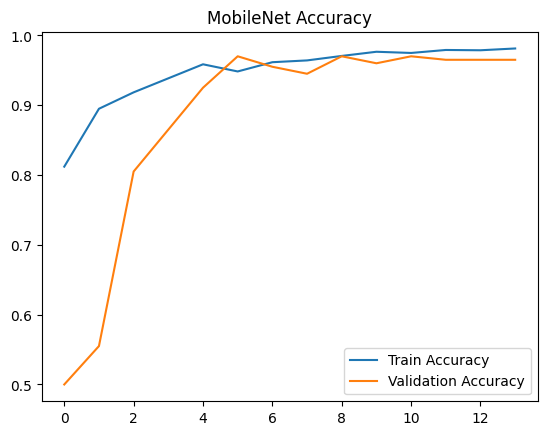

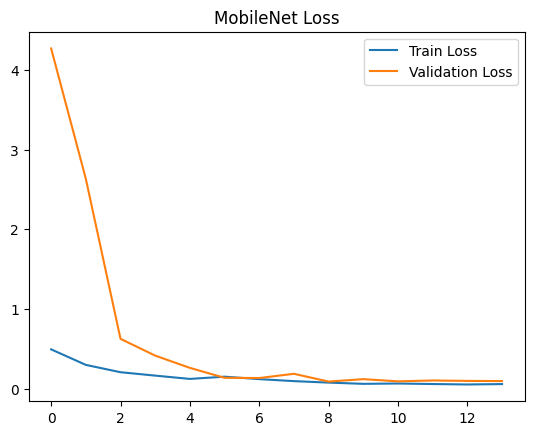

In [28]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("MobileNet Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("MobileNet Loss")
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 493ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       100
           1       0.89      1.00      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



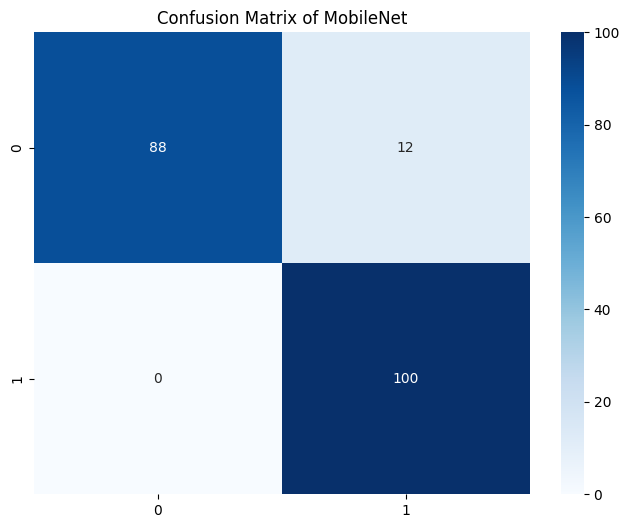

In [29]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNet")
plt.show()

# **AUC-ROC**

In [32]:
y_prob = model.predict(test_gen)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


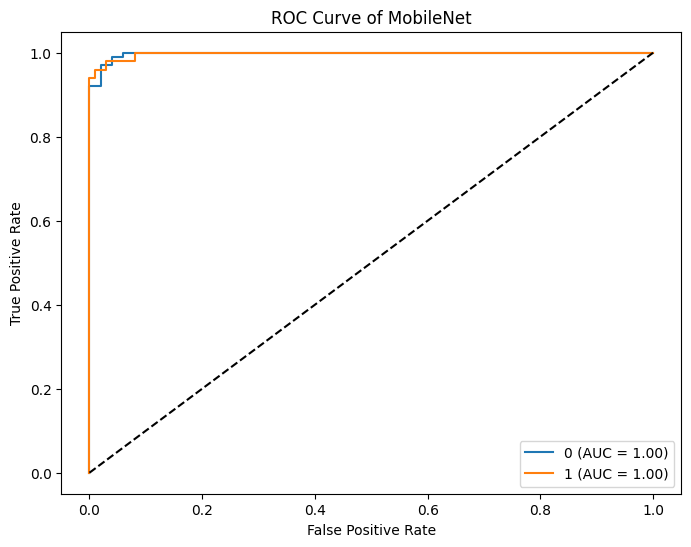

In [33]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
class_names = list(test_gen.class_indices.keys())
n_classes = len(class_names)

# True labels
y_true = np.array(test_gen.classes) # Converted to NumPy array here

# Predicted probabilities (softmax outputs)
y_prob = model.predict(test_gen)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    # For each class, treat it as the positive class
    # Convert y_true to binary labels (1 if it's class i, 0 otherwise)
    y_true_for_class_i = (y_true == i).astype(int)

    # Use the probabilities for class i
    y_score_for_class_i = y_prob[:, i]

    fpr, tpr, _ = roc_curve(y_true_for_class_i, y_score_for_class_i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Random chance line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve of MobileNet")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# **Compute Flops,Measure Inference Time,Memory Consumption**

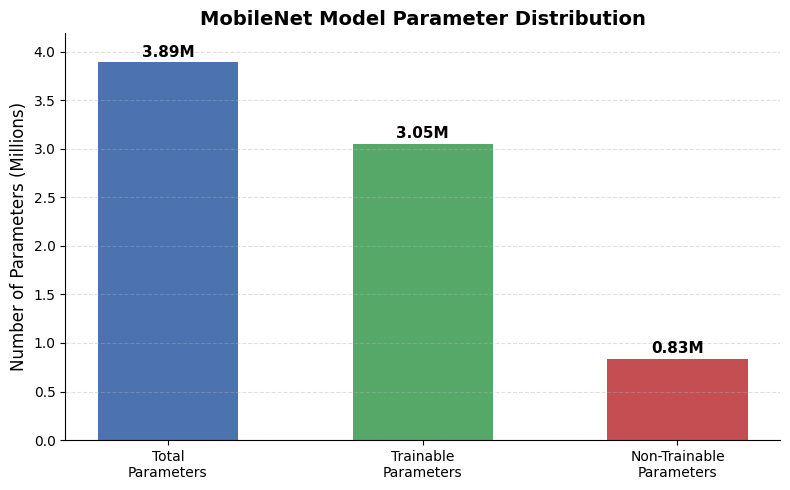

In [34]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Get parameters automatically
total_params = model.count_params()

trainable_params = sum(
    [tf.keras.backend.count_params(w) for w in model.trainable_weights]
)

non_trainable_params = sum(
    [tf.keras.backend.count_params(w) for w in model.non_trainable_weights]
)

# Convert to millions
params = [
    total_params / 1e6,
    trainable_params / 1e6,
    non_trainable_params / 1e6
]

labels = [
    "Total\nParameters",
    "Trainable\nParameters",
    "Non-Trainable\nParameters"
]

# Add colors
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    params,
    width=0.55,
    color=colors
)

# Add values above bars
for bar, value in zip(bars, params):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f"{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylabel("Number of Parameters (Millions)", fontsize=12)
plt.title(
    "MobileNet Model Parameter Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.ylim(0, max(params) + 0.3)

plt.tight_layout()
plt.show()

I0000 00:00:1783319012.622916      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1783319012.623111      58 single_machine.cc:376] Starting new session
I0000 00:00:1783319012.638664      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783319012.640371      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

2026-07-06 06:23:40.217160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 06:23:40.368208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 06:23:40.502193: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


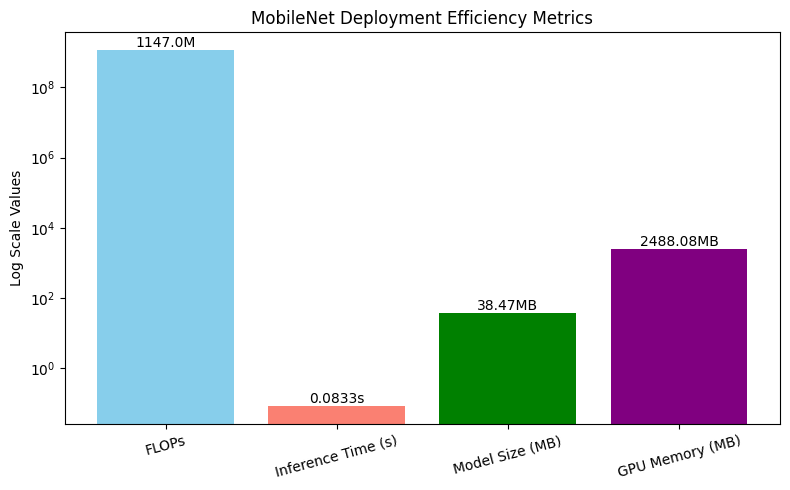

In [35]:
import tensorflow as tf
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2


# ============================================================
# 1. FLOPs CALCULATION
# ============================================================
def get_flops(model):
    input_shape = [1] + list(model.input_shape[1:])

    concrete_func = tf.function(lambda x: model(x))
    concrete_func = concrete_func.get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )
        return flops.total_float_ops


flops = get_flops(model)


# ============================================================
# 2. INFERENCE TIME
# ============================================================
x_sample = np.random.rand(1, 224, 224, 3).astype(np.float32)

_ = model.predict(x_sample, verbose=0)  # warm-up

start = time.time()
_ = model.predict(x_sample, verbose=0)
inference_time = time.time() - start


# ============================================================
# 3. MODEL SIZE (NEW IMPORTANT METRIC)
# ============================================================
model_path = "temp_model.keras"
model.save(model_path)

model_size = os.path.getsize(model_path) / (1024 ** 2)  # MB
os.remove(model_path)


# ============================================================
# 4. GPU MEMORY (optional, safe version)
# ============================================================
gpu_memory = 0
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        details = tf.config.experimental.get_memory_info("GPU:0")
        gpu_memory = details['peak'] / (1024 ** 2)
    except:
        gpu_memory = 0


# ============================================================
# 5. PLOT METRICS
# ============================================================
metrics = ['FLOPs', 'Inference Time (s)', 'Model Size (MB)']
values = [flops, inference_time, model_size]

if gpu_memory > 0:
    metrics.append('GPU Memory (MB)')
    values.append(gpu_memory)


plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['skyblue', 'salmon', 'green', 'purple'])

plt.yscale('log')
plt.title("MobileNet Deployment Efficiency Metrics")
plt.ylabel("Log Scale Values")
plt.xticks(rotation=15)

# Annotate values
for i, bar in enumerate(bars):
    height = bar.get_height()

    if metrics[i] == 'FLOPs':
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height/1e6:.1f}M',
                 ha='center',
                 va='bottom')
    elif metrics[i] == 'Inference Time (s)':
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.4f}s',
                 ha='center',
                 va='bottom')
    else:
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.2f}MB',
                 ha='center',
                 va='bottom')

plt.tight_layout()
plt.show()

# **Bootstrap Confidence Interval for Accuracy**
statistical significance testing 


Bootstrap Accuracy CI:
Mean Accuracy: 0.9394
95% CI: [0.9050, 0.9700]


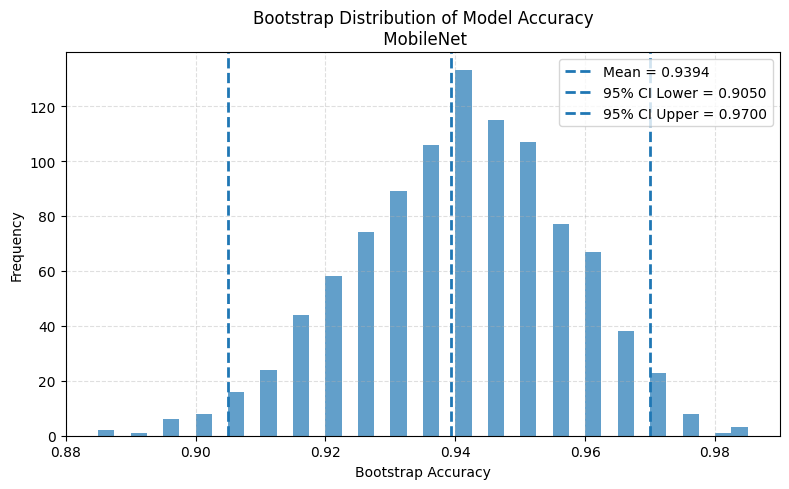

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def bootstrap_ci(y_true, y_pred, n_iterations=1000, confidence=0.95):

    scores = []

    n = len(y_true)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for _ in range(n_iterations):

        indices = np.random.randint(
            0,
            n,
            n
        )

        score = accuracy_score(
            y_true[indices],
            y_pred[indices]
        )

        scores.append(score)

    scores = np.array(scores)

    lower = np.percentile(
        scores,
        (1-confidence)/2*100
    )

    upper = np.percentile(
        scores,
        (1+confidence)/2*100
    )

    return scores, np.mean(scores), lower, upper



# Run bootstrap
bootstrap_scores, mean_acc, lower, upper = bootstrap_ci(
    y_true,
    y_pred
)


print("\nBootstrap Accuracy CI:")
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"95% CI: [{lower:.4f}, {upper:.4f}]")


# ============================================================
# PLOT BOOTSTRAP DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    bootstrap_scores,
    bins=40,
    alpha=0.7
)

# Mean line
plt.axvline(
    mean_acc,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_acc:.4f}"
)

# CI lines
plt.axvline(
    lower,
    linestyle="--",
    linewidth=2,
    label=f"95% CI Lower = {lower:.4f}"
)

plt.axvline(
    upper,
    linestyle="--",
    linewidth=2,
    label=f"95% CI Upper = {upper:.4f}"
)


plt.xlabel("Bootstrap Accuracy")
plt.ylabel("Frequency")

plt.title(
    "Bootstrap Distribution of Model Accuracy\n MobileNet"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# **TTA**

TTA Accuracy: 0.9400


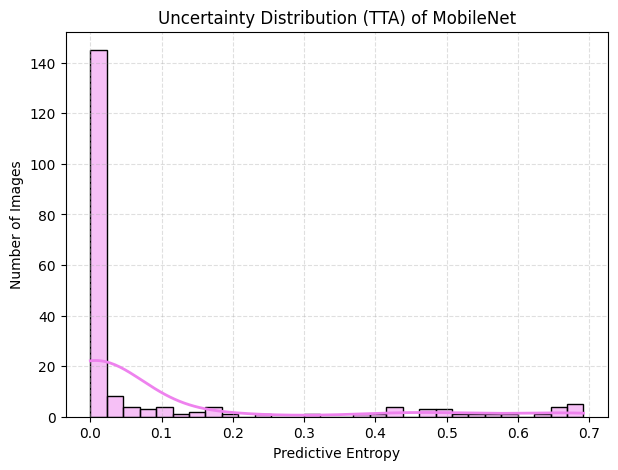

In [37]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications.mobilenet import preprocess_input

# -----------------------------
# TTA parameters
# -----------------------------
tta_steps = 10
img_size = (224, 224)
batch_size = 32


def apply_strong(img):
    # Ensure RGB and resize
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)

    # Example strong augmentations for MixMatch
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # horizontal flip
    factor = 0.9 + 0.2 * np.random.rand()  # brightness [0.9,1.1]
    img = np.clip(img * factor, 0, 255).astype(np.uint8)

    return img

# -----------------------------
# Prepare test images
# -----------------------------
image_paths = test_df['image_path'].tolist()
all_probs = []

for step in range(tta_steps):
    batch_images = []
    for path in image_paths:
        img = cv2.imread(path)
        img_aug = apply_strong(img)
        batch_images.append(img_aug)

    batch_images = np.stack(batch_images, axis=0)
    batch_images = preprocess_input(batch_images)  # MixMatch uses MobileNet preprocessing

    # Predict probabilities
    probs = model.predict(batch_images, batch_size=batch_size, verbose=0)
    all_probs.append(probs)

# -----------------------------
# Average predictions across TTA
# -----------------------------
y_prob_tta = np.mean(all_probs, axis=0)
y_pred_tta = np.argmax(y_prob_tta, axis=1)

# True labels
y_true = test_gen.classes

# Compute TTA accuracy
tta_acc = np.mean(y_pred_tta == y_true)
print(f"TTA Accuracy: {tta_acc:.4f}")

# -----------------------------
# Predictive entropy for uncertainty
# -----------------------------
entropy = -np.sum(y_prob_tta * np.log(y_prob_tta + 1e-8), axis=1)

# Plot histogram of predictive entropy
plt.figure(figsize=(7,5))
sns.histplot(entropy, bins=30, kde=True, color="violet",
             line_kws={"linewidth": 2, "color": "violet"})
plt.title("Uncertainty Distribution (TTA) of MobileNet")
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Images")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# **TTA Improvement Comparison Plot**

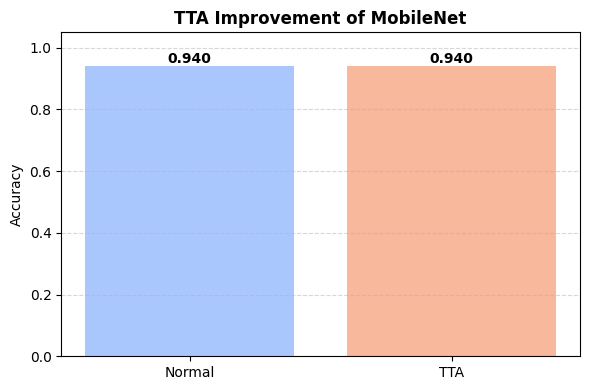

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

normal_acc = np.mean(y_pred == y_true)
tta_acc = np.mean(y_pred_tta == y_true)

accs = [normal_acc, tta_acc]
labels = ["Normal", "TTA"]

colors = sns.color_palette("coolwarm", 2)

plt.figure(figsize=(6,4))

bars = plt.bar(labels, accs, color=colors, linewidth=1.2)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.3f}",
             ha='center', fontsize=10, fontweight='bold')

plt.title("TTA Improvement of MobileNet",
          fontsize=12, fontweight='bold')

plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

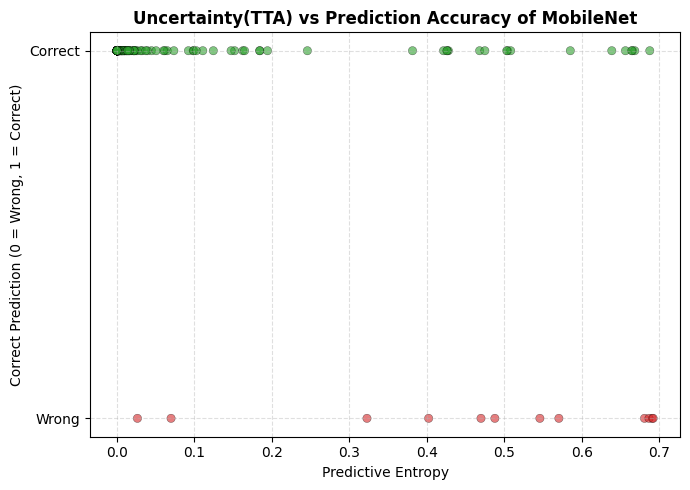

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

correct = (y_pred_tta == y_true)

plt.figure(figsize=(7,5))

# Color by correctness (very useful for analysis)
colors = np.where(correct, "#2ca02c", "#d62728")  # green = correct, red = wrong

plt.scatter(entropy, correct, c=colors, alpha=0.6, edgecolor='black', linewidth=0.3)

plt.title("Uncertainty(TTA) vs Prediction Accuracy of MobileNet",
          fontsize=12, fontweight='semibold')

plt.xlabel("Predictive Entropy")
plt.ylabel("Correct Prediction (0 = Wrong, 1 = Correct)")

plt.yticks([0, 1], ["Wrong", "Correct"])

plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# **Prediction Confidence Distribution**

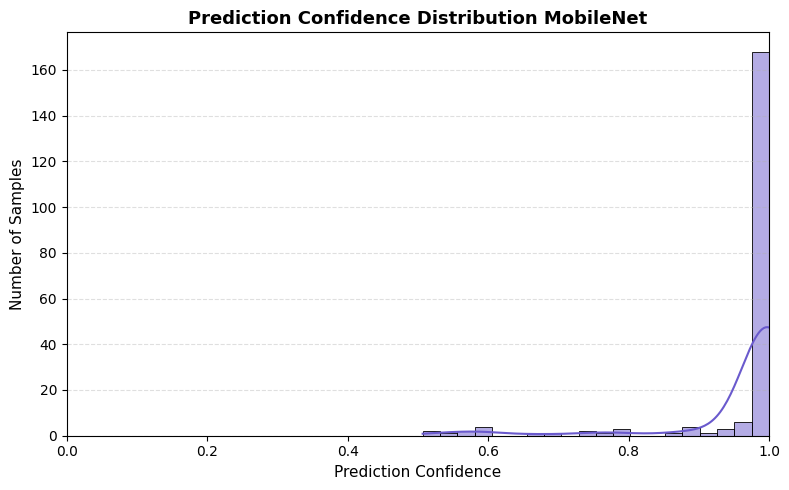

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

confidence = np.max(y_prob, axis=1)

plt.figure(figsize=(8,5))

# Histogram with KDE overlay for smooth distribution
sns.histplot(confidence,
             bins=20,
             kde=True,
             color="#6a5acd",
             edgecolor="black",
             linewidth=0.6)

# Styling
plt.title("Prediction Confidence Distribution MobileNet",
          fontsize=13, fontweight='bold')

plt.xlabel("Prediction Confidence", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)

plt.xlim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# **ECE**

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
Expected Calibration Error (ECE): 0.0289


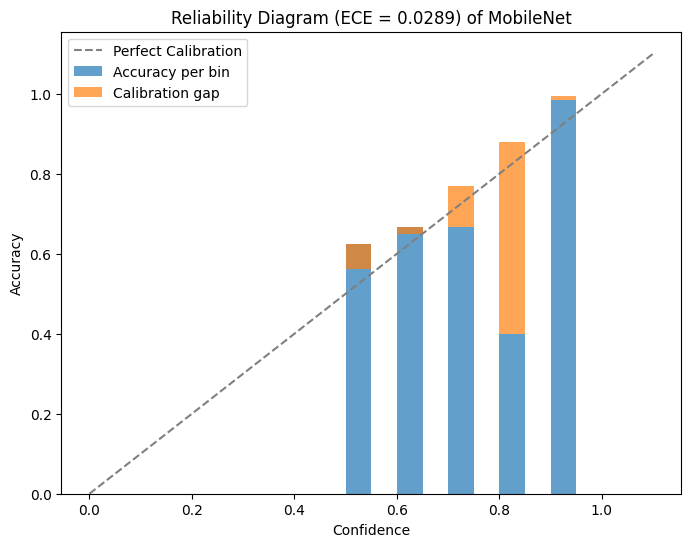

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(probs, labels, n_bins=10):
    """
    Compute Expected Calibration Error (ECE)
    
    probs: array of shape (num_samples, num_classes), predicted probabilities
    labels: array of shape (num_samples,), true class indices
    n_bins: number of bins for calibration
    """
    labels = np.array(labels)  # ensure labels is a numpy array
    confidences = np.max(probs, axis=1)  # predicted probability of the predicted class
    predictions = np.argmax(probs, axis=1)
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_acc = []
    bin_conf = []
    bin_sizes = []

    for i in range(n_bins):
        lower, upper = bin_edges[i], bin_edges[i+1]
        mask = (confidences > lower) & (confidences <= upper)
        bin_size = np.sum(mask)
        
        if bin_size > 0:
            acc = np.mean((predictions[mask] == labels[mask]))
            conf = np.mean(confidences[mask])
            ece += (bin_size / len(labels)) * abs(acc - conf)
        else:
            acc, conf = 0, 0
        
        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(bin_size)
    
    return ece, bin_acc, bin_conf, bin_sizes

# Convert predictions to probabilities if not already
y_probs = model.predict(test_gen)  # shape: (num_samples, num_classes)
y_true_array = np.array(test_gen.classes)  # convert to numpy array

# Compute ECE
ece, bin_acc, bin_conf, bin_sizes = compute_ece(y_probs, y_true_array, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# Plot reliability diagram
plt.figure(figsize=(8,6))
plt.plot([0,1.1], [0,1.1], linestyle='--', color='gray', label='Perfect Calibration')
plt.bar(np.arange(10)/10 + 0.05/2, bin_acc, width=0.05, alpha=0.7, label='Accuracy per bin')
plt.bar(np.arange(10)/10 + 0.05/2, np.array(bin_conf)-np.array(bin_acc), bottom=bin_acc, width=0.05, alpha=0.7, label='Calibration gap')

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.4f}) of MobileNet")
plt.legend()
plt.show()

# **Grad-Cam**

In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ============================================================
# FIND LAST CONV LAYER AUTOMATICALLY
# ============================================================
def get_last_conv_layer(model):
    # safer: check layer output tensor shape
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except:
            continue
    return None

last_conv_layer_name = get_last_conv_layer(model)
print("Last Conv Layer:", last_conv_layer_name)


Last Conv Layer: conv_pw_13_relu



Grad-CAM for class 0: /kaggle/working/train1/benign/SOB_B_A-14-22549AB-40-017.png

Grad-CAM for class 0: /kaggle/working/train1/benign/SOB_B_A-14-22549AB-40-017.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s
Predicted class id: 0 | Probability: 0.996
True class: 0


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


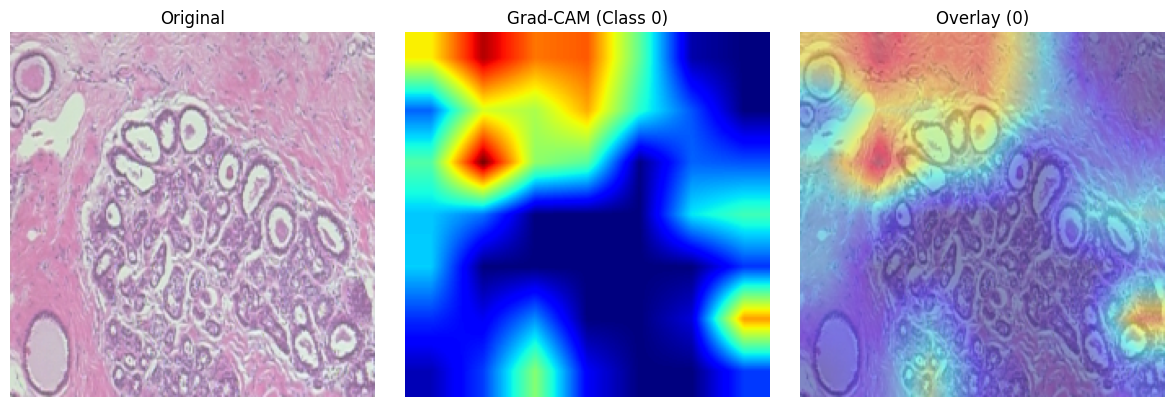


Grad-CAM for class 1: /kaggle/working/train1/malignant/SOB_M_MC-14-12773-40-009.png

Grad-CAM for class 1: /kaggle/working/train1/malignant/SOB_M_MC-14-12773-40-009.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s
Predicted class id: 1 | Probability: 1.000
True class: 1


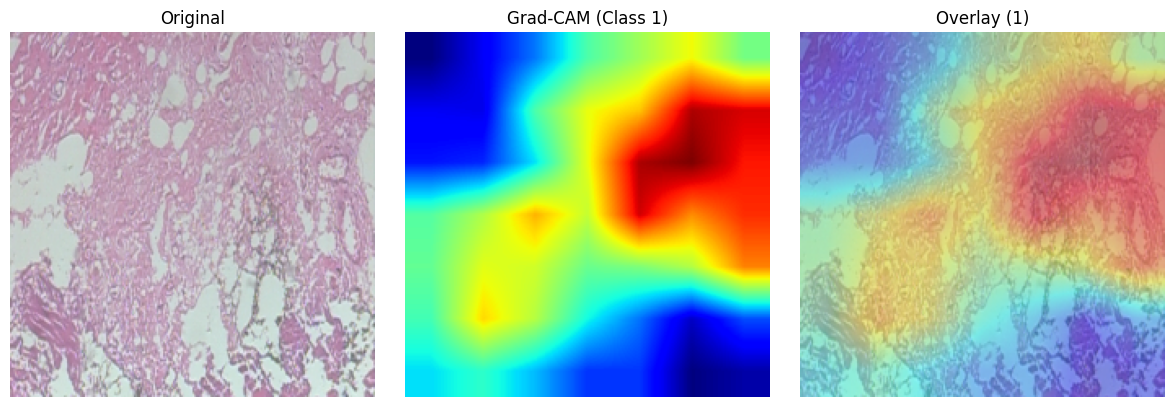

In [44]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


# ============================================================
# GRAD-CAM HEATMAP FUNCTION (FIXED)
# ============================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_index):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # ✅ FIX: safe TensorFlow indexing
        class_channel = tf.gather(predictions, class_index, axis=1)

    # gradients of target class w.r.t conv outputs
    grads = tape.gradient(class_channel, conv_outputs)

    # global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


# ============================================================
# DISPLAY GRAD-CAM FUNCTION
# ============================================================
def display_gradcam(
    img_path,
    model,
    last_conv_layer_name,
    class_index,
    class_name=None,
    alpha=0.4,
    img_size=(224, 224)
):

    # -------------------------
    # Load image
    # -------------------------
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)

    # -------------------------
    # Preprocess (MobileNetV3)
    # -------------------------
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = preprocess_input(img_array_exp)

    # -------------------------
    # Prediction
    # -------------------------
    preds = model.predict(img_array_exp, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_prob = np.max(preds[0])

    print(f"\nGrad-CAM for class {class_index}: {img_path}")
    print("1/1 ━━━━━━━━━━━━━━━━━━━━ 0s")
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")

    if class_name is not None:
        print(f"True class: {class_name}")

    # -------------------------
    # Grad-CAM heatmap
    # -------------------------
    heatmap = make_gradcam_heatmap(
        img_array_exp,
        model,
        last_conv_layer_name,
        class_index
    )

    heatmap_resized = cv2.resize(heatmap, img_size)

    # -------------------------
    # Heatmap overlay
    # -------------------------
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(
        original_img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    # -------------------------
    # Visualization
    # -------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title(f"Grad-CAM (Class {class_index})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))

    title = "Overlay"
    if class_name:
        title += f" ({class_name})"

    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN FOR MULTIPLE CLASSES
# ============================================================
class_ids = test_df['label_num'].unique()

for cls in class_ids:
    img_path = test_df[test_df['label_num'] == cls]['image_path'].iloc[6]

    print(f"\nGrad-CAM for class {cls}: {img_path}")

    display_gradcam(
        img_path=img_path,
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        class_index=int(cls),
        class_name=str(cls)
    )


Grad-CAM for class 0: /kaggle/working/train1/benign/SOB_B_F-14-14134-40-003.png

Grad-CAM for class 0: /kaggle/working/train1/benign/SOB_B_F-14-14134-40-003.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s
Predicted class id: 0 | Probability: 1.000
True class: 0


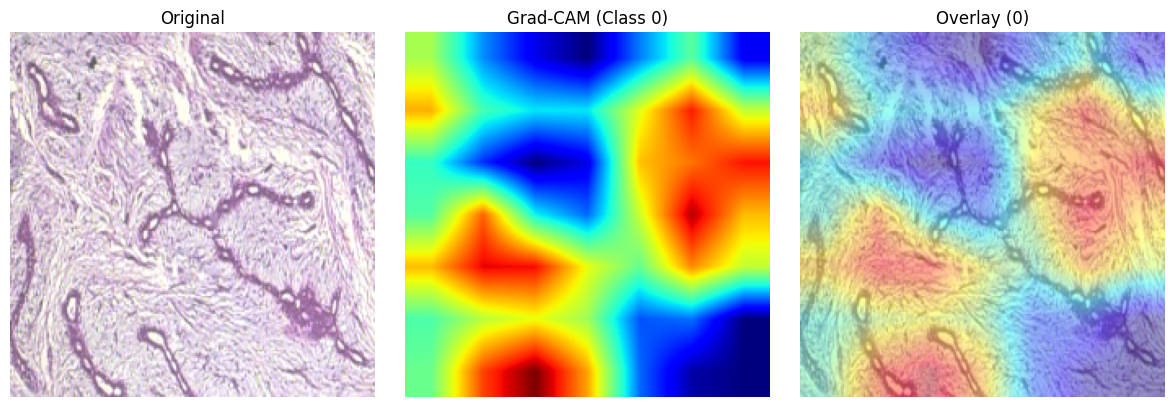


Grad-CAM for class 1: /kaggle/working/train1/malignant/SOB_M_MC-14-19979C-40-016.png

Grad-CAM for class 1: /kaggle/working/train1/malignant/SOB_M_MC-14-19979C-40-016.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s
Predicted class id: 1 | Probability: 0.999
True class: 1


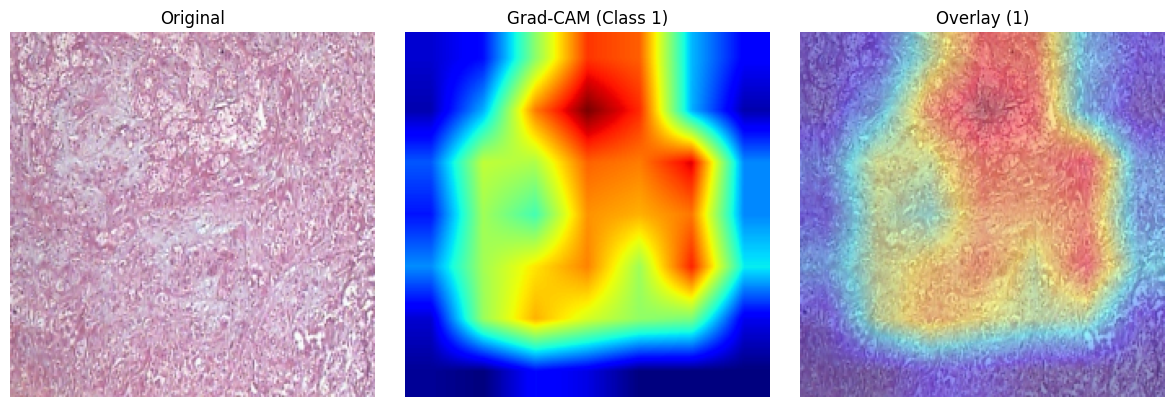

In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


# ============================================================
# GRAD-CAM HEATMAP FUNCTION (FIXED)
# ============================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_index):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # ✅ FIX: safe TensorFlow indexing
        class_channel = tf.gather(predictions, class_index, axis=1)

    # gradients of target class w.r.t conv outputs
    grads = tape.gradient(class_channel, conv_outputs)

    # global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


# ============================================================
# DISPLAY GRAD-CAM FUNCTION
# ============================================================
def display_gradcam(
    img_path,
    model,
    last_conv_layer_name,
    class_index,
    class_name=None,
    alpha=0.4,
    img_size=(224, 224)
):

    # -------------------------
    # Load image
    # -------------------------
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)

    # -------------------------
    # Preprocess (MobileNetV3)
    # -------------------------
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = preprocess_input(img_array_exp)

    # -------------------------
    # Prediction
    # -------------------------
    preds = model.predict(img_array_exp, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_prob = np.max(preds[0])

    print(f"\nGrad-CAM for class {class_index}: {img_path}")
    print("1/1 ━━━━━━━━━━━━━━━━━━━━ 0s")
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")

    if class_name is not None:
        print(f"True class: {class_name}")

    # -------------------------
    # Grad-CAM heatmap
    # -------------------------
    heatmap = make_gradcam_heatmap(
        img_array_exp,
        model,
        last_conv_layer_name,
        class_index
    )

    heatmap_resized = cv2.resize(heatmap, img_size)

    # -------------------------
    # Heatmap overlay
    # -------------------------
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(
        original_img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    # -------------------------
    # Visualization
    # -------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title(f"Grad-CAM (Class {class_index})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))

    title = "Overlay"
    if class_name:
        title += f" ({class_name})"

    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN FOR MULTIPLE CLASSES
# ============================================================
class_ids = test_df['label_num'].unique()

for cls in class_ids:
    img_path = test_df[test_df['label_num'] == cls]['image_path'].iloc[0]

    print(f"\nGrad-CAM for class {cls}: {img_path}")

    display_gradcam(
        img_path=img_path,
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        class_index=int(cls),
        class_name=str(cls)
    )